In [ ]:
%load_ext autoreload
%autoreload 2

from spatial_tcr.utils import switch_cwd_to_root

switch_cwd_to_root()

import warnings

import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import seaborn as sns

from spatial_tcr.clustering import (
    leiden_unique,
)
from spatial_tcr.tcr import get_tcr_genes

# Suppress performance warnings

warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

Changed working directory to /bonn-epyc/projects/dschaub/analysis-projects/spatial-tcr


In [7]:
def flatten_dict(d):
    return [i for items in d.values() for i in items]

In [8]:
adata = sc.read_h5ad("data/xenium/processed/03-kidney_tcr_classified.h5ad")
adata.X = adata.layers["counts"].copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.layers["log1p"] = adata.X.copy()
adata.X = adata.layers["counts"].copy()
adata, adata.X.max()

(AnnData object with n_obs × n_vars = 510139 × 480
     obs: 'sample', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob'
     var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
     uns: 'graph', 'log1p'
     obsm: 'cell_type_no_tcr_probs', 'spatial'
     layers: 'counts', 'log1p',
 np.float32(136.0))

In [21]:
mask = (
    adata[
        :, ["CD3D", "CD3E", "CD3G", "CD8A", "TRBC1", "TRBC2", "TRDC", "TRGC1", "TRGC2"]
    ]
    .X.toarray()
    .sum(axis=1)
    > 0
)
adata[mask].obs["cell_type_no_tcr"].value_counts()

cell_type_no_tcr
T           30587
PT          20300
Mac         13277
FIB         12919
MDC          6223
TAL          6127
EC           4768
IC           4176
PC           3182
B            2634
PL           2234
CNT          2127
VSM/P        1705
DCT          1457
DTL           814
POD           718
PEC           669
glom. EC      570
cycMNP        400
MAST          221
MC            188
N             121
cDC            71
ATL            54
PapE            7
pDC             4
NEU             3
Name: count, dtype: int64

In [22]:
adata.obs["slide"].value_counts()

slide
0029041    281599
0029040    228540
Name: count, dtype: int64

In [23]:
ad_t = adata[adata.obs["cell_type_no_tcr"] == "T"].copy()
ad_t

AnnData object with n_obs × n_vars = 33836 × 480
    obs: 'sample', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'graph', 'log1p'
    obsm: 'cell_type_no_tcr_probs', 'spatial'
    layers: 'counts', 'log1p'

In [24]:
av_genes, bv_genes, dv_genes, gv_genes, tv_genes = get_tcr_genes(ad_t)

Found 54 TRAV genes, 61 TRBV genes, 3 TRDV genes, 14 TRGV genes


In [25]:
markers = {
    "MAIT": ["TRAV1-2"],
    "gdT": ["TRDC", "TRGC1", "TRGC2"],
    "CD8": [
        "CD8A",
        "GZMK",
        "GZMH",
        "GZMB",
    ],
    "CD4": [
        "CD4",
        "IL23A",
    ],
}
markers_flattend = [gene for genes in markers.values() for gene in genes]
markers_flattend = []

In [26]:
var_names = [v for v in ad_t.var_names if v not in tv_genes]
var_names = [v for v in var_names if v not in markers_flattend] + markers_flattend

ad_t = ad_t[:, var_names].copy()
print(ad_t.shape)
# remove cells with zero expression
sc.pp.filter_cells(ad_t, min_genes=1)
print(ad_t.shape)

(33836, 348)
(33836, 348)


In [27]:
sc.pp.normalize_total(ad_t)
sc.pp.log1p(ad_t)

In [28]:
sc.pp.highly_variable_genes(ad_t, n_top_genes=100, batch_key="sample")

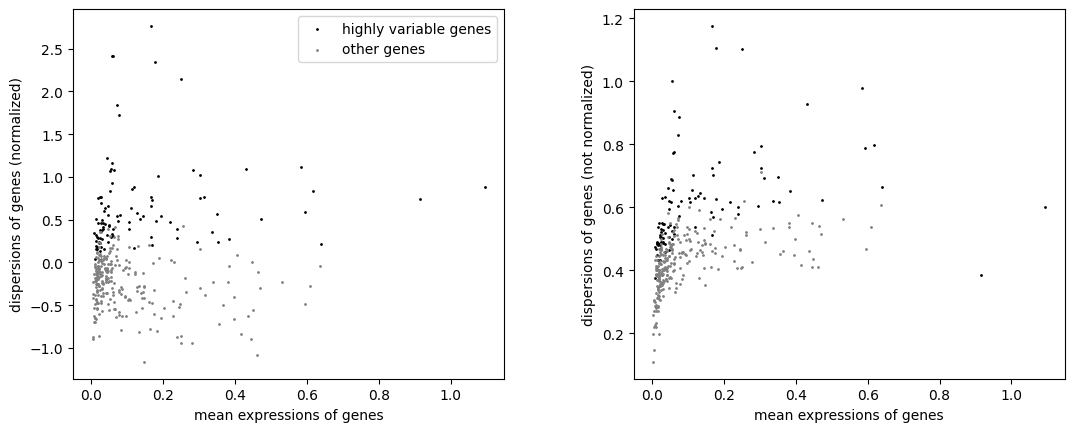

In [29]:
sc.pl.highly_variable_genes(ad_t)

In [30]:
reduced_var_names = ad_t.var_names[ad_t.var["highly_variable"]].tolist()
reduced_var_names = [
    v for v in reduced_var_names if v not in markers_flattend
] + markers_flattend
ad_t = ad_t[:, reduced_var_names].copy()
ad_t

AnnData object with n_obs × n_vars = 33836 × 100
    obs: 'sample', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob', 'n_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'graph', 'log1p', 'hvg'
    obsm: 'cell_type_no_tcr_probs', 'spatial'
    layers: 'counts', 'log1p'

In [31]:
# remove cells with zero expression
print(ad_t.shape)
sc.pp.filter_cells(ad_t, min_genes=5)
print(ad_t.shape)

(33836, 100)
(31595, 100)


In [32]:
ad_t.X = ad_t.layers["counts"].copy()
sc.pp.normalize_total(ad_t)
sc.pp.log1p(ad_t)
sc.tl.pca(ad_t, n_comps=50)

In [33]:
# sc.pl.pca_variance_ratio(ad_t, n_pcs=50, log=True)
# sc.pl.pca(ad_t, color=["slide"])

In [34]:
ad_t.obsm["X_pca"][0]

array([-6.88336611e-01,  8.56149316e-01, -1.31131971e+00,  7.19045758e-01,
       -6.00011528e-01, -7.61083036e-04, -1.09832130e-01,  1.06228197e+00,
       -5.04678369e-01, -4.56718914e-02, -1.39269978e-02,  3.02117560e-02,
       -2.83668004e-02, -4.10674587e-02, -4.10354912e-01,  2.85891086e-01,
       -3.11997384e-01, -6.15366995e-01, -2.59853780e-01,  5.71850479e-01,
        1.04640476e-01, -5.49928844e-02, -1.45575276e-03, -8.99030864e-01,
       -3.34395468e-01, -5.01447737e-01,  6.92548454e-01,  2.24716306e-01,
        1.28589243e-01, -2.34273747e-01,  8.46982077e-02, -4.37969677e-02,
       -2.02516794e-01,  3.16399336e-02,  1.53757527e-01, -1.03389479e-01,
       -1.23437367e-01, -1.09440815e-02,  1.15463831e-01, -1.28659811e-02,
       -1.30728200e-01,  3.14762853e-02, -2.91531384e-02, -7.34734535e-02,
       -2.77701497e-01, -1.05291680e-01, -2.58678254e-02, -7.95458928e-02,
        9.22042653e-02,  2.24041771e-02], dtype=float32)

In [146]:
ad_t.obsm["X_pca"][0]

array([-6.88334465e-01,  8.56148601e-01, -1.31131876e+00,  7.19052434e-01,
       -6.00005388e-01, -7.68525235e-04, -1.09825209e-01,  1.06227505e+00,
       -5.04694223e-01, -4.56753150e-02, -1.39265992e-02,  3.02089285e-02,
       -2.83668805e-02, -4.10693176e-02, -4.10351187e-01,  2.85882920e-01,
       -3.12006593e-01, -6.15366638e-01, -2.59853333e-01,  5.71852267e-01,
        1.04648247e-01, -5.49845621e-02, -1.44428632e-03, -8.99030983e-01,
       -3.34391832e-01, -5.01443267e-01,  6.92561209e-01,  2.24699095e-01,
        1.28590778e-01, -2.34270036e-01,  8.47005025e-02, -4.37982827e-02,
       -2.02515602e-01,  3.16399597e-02,  1.53758243e-01, -1.03390232e-01,
       -1.23436831e-01, -1.09445546e-02,  1.15462489e-01, -1.28658954e-02,
       -1.30728006e-01,  3.14759500e-02, -2.91543826e-02, -7.34727830e-02,
       -2.77701169e-01, -1.05290145e-01, -2.58711465e-02, -7.95403346e-02,
        9.22073722e-02,  2.24022921e-02], dtype=float32)

In [147]:
leiden_unique(
    ad_t, use_rep="X_pca", resolution=2.0, n_neighbors=50, key_added="leiden_tcell"
)

Found 31592 unique embeddings from a total of 31595


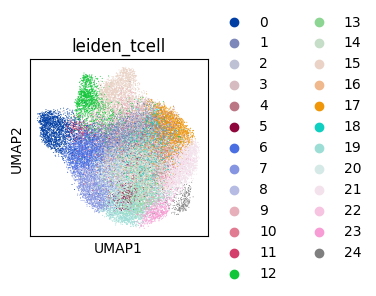

In [148]:
sc.pp.neighbors(ad_t, use_rep="X_pca", n_neighbors=15)
sc.tl.umap(ad_t)
sc.pl.umap(
    ad_t,
    color="leiden_tcell",
    # Setting a smaller point size to get prevent overlap
    size=2,
)

## Add back all original genes

In [149]:
ad_t_full = adata[ad_t.obs_names].copy()
sc.pp.normalize_total(ad_t_full)
sc.pp.log1p(ad_t_full)
ad_t_full.obsm["X_pca"] = ad_t.obsm["X_pca"]
ad_t_full.obs["leiden_tcell"] = ad_t.obs["leiden_tcell"].copy()
sc.pp.neighbors(ad_t_full, use_rep="X_pca", n_neighbors=15)
sc.tl.umap(ad_t_full)

In [150]:
ad_t_full.obs["leiden_tcell"].value_counts()

leiden_tcell
21    2775
1     2172
14    2129
6     2126
15    2081
7     2047
17    1940
20    1914
19    1847
0     1842
12    1595
18    1312
23    1158
4      940
13     877
8      820
10     706
3      677
9      618
11     446
16     441
5      377
24     296
2      295
22     164
Name: count, dtype: int64

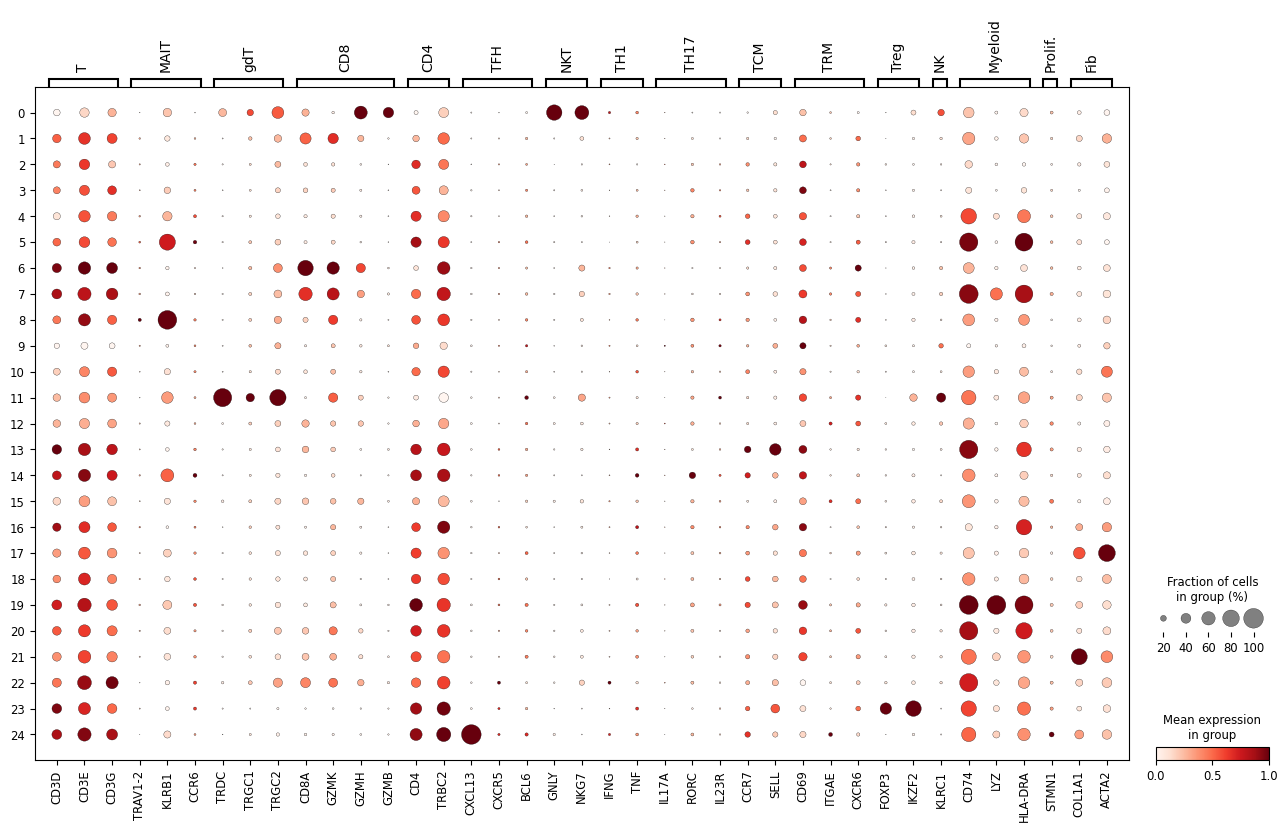

In [151]:
markers = {
    "T": ["CD3D", "CD3E", "CD3G"],
    "MAIT": ["TRAV1-2", "KLRB1", "CCR6"],
    "gdT": ["TRDC", "TRGC1", "TRGC2"],
    "CD8": [
        "CD8A",
        "GZMK",
        "GZMH",
        "GZMB",
    ],
    "CD4": ["CD4", "TRBC2"],
    "TFH": ["CXCL13", "CXCR5", "BCL6"],
    "NKT": ["GNLY", "NKG7"],
    "TH1": ["IFNG", "TNF"],
    "TH17": ["IL17A", "RORC", "IL23R"],
    "TCM": ["CCR7", "SELL"],
    "TRM": ["CD69", "ITGAE", "CXCR6"],
    "Treg": ["FOXP3", "IKZF2"],
    "NK": ["KLRC1"],
    "Myeloid": ["CD74", "LYZ", "HLA-DRA"],
    "Prolif.": ["STMN1"],
    "Fib": ["COL1A1", "ACTA2"],
}
sc.pl.dotplot(ad_t_full, markers, groupby="leiden_tcell", standard_scale="var")

In [152]:
# sc.pl.dotplot(adata, markers, groupby="cell_type_no_tcr", standard_scale="var")

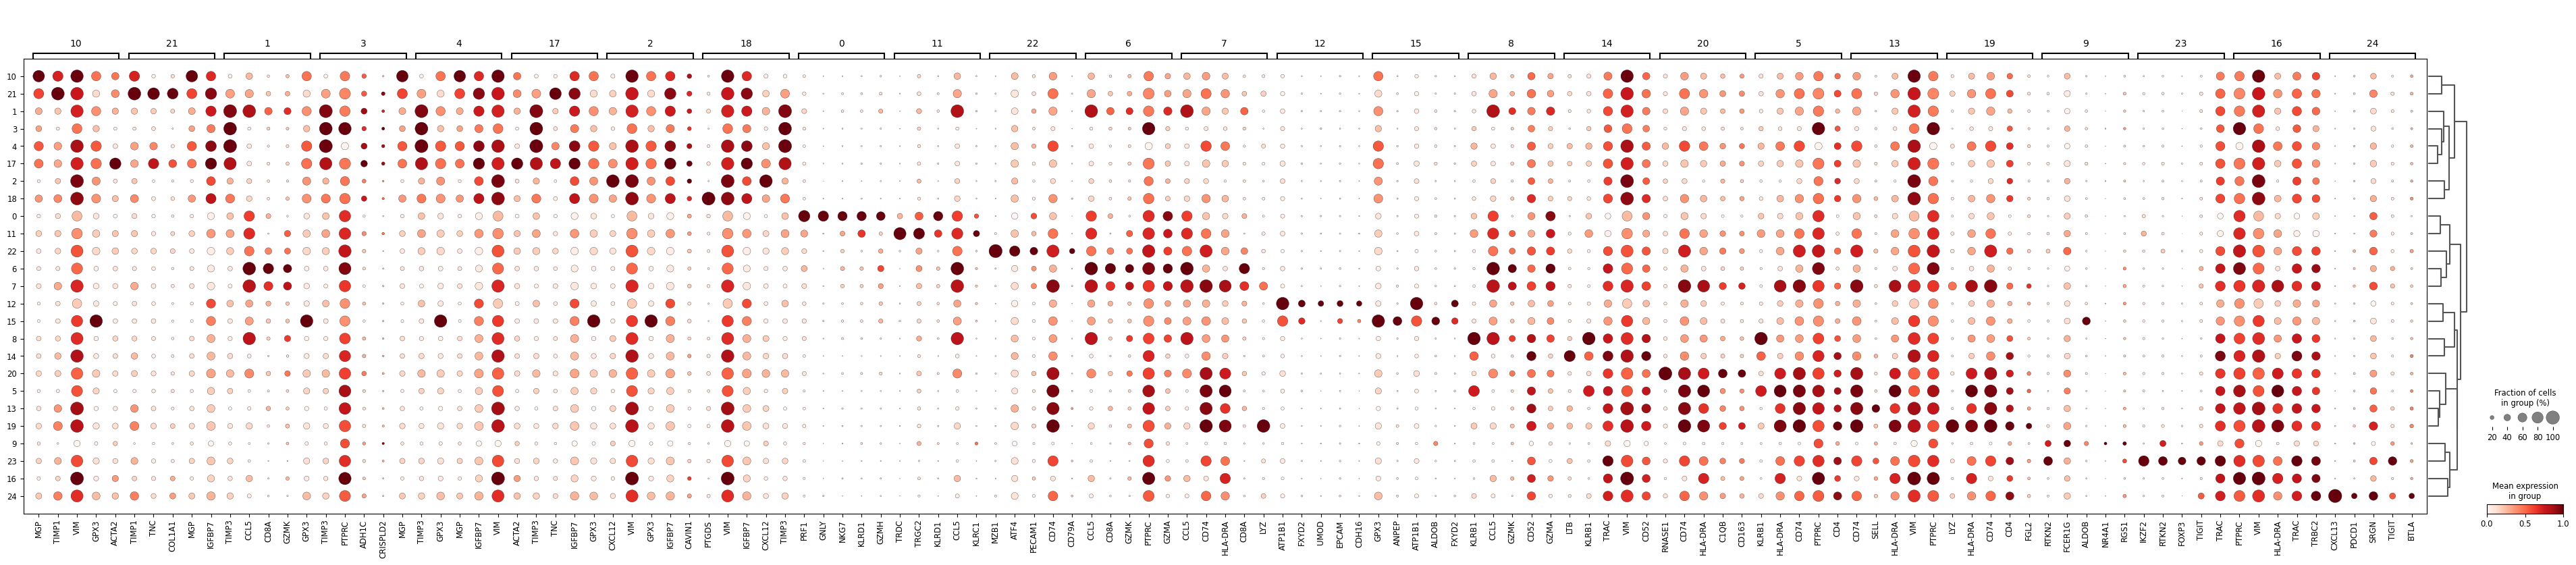

In [153]:
# check differential gene expression
# Obtain cluster-specific differentially expressed genes
sc.tl.rank_genes_groups(ad_t_full, groupby="leiden_tcell", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(
    ad_t_full, groupby="leiden_tcell", standard_scale="var", n_genes=5
)

In [154]:
# extract all these markers
degs = {
    g: sc.get.rank_genes_groups_df(ad_t_full, group=g).head(8).names.tolist()
    for g in ad_t_full.obs["leiden_tcell"].value_counts().index
}
degs

{'21': ['TIMP1', 'TNC', 'COL1A1', 'MGP', 'IGFBP7', 'CFH', 'SERPINF1', 'ACTA2'],
 '1': ['TIMP3', 'CCL5', 'CD8A', 'GZMK', 'GPX3', 'IGFBP7', 'GZMA', 'ADH1C'],
 '14': ['LTB', 'KLRB1', 'TRAC', 'VIM', 'CD52', 'RORC', 'CD4', 'PTPRC'],
 '6': ['CCL5', 'CD8A', 'GZMK', 'PTPRC', 'GZMA', 'GZMH', 'CCL4', 'TRGC2'],
 '15': ['GPX3', 'ANPEP', 'ATP1B1', 'ALDOB', 'FXYD2', 'GATM', 'NAT8', 'SMIM24'],
 '7': ['CCL5', 'CD74', 'HLA-DRA', 'CD8A', 'LYZ', 'GZMK', 'GZMA', 'C1QB'],
 '17': ['ACTA2', 'TIMP3', 'TNC', 'IGFBP7', 'GPX3', 'COL1A1', 'CXCL12', 'MGP'],
 '20': ['RNASE1',
  'CD74',
  'HLA-DRA',
  'C1QB',
  'CD163',
  'MRC1',
  'CXCL12',
  'APOE'],
 '19': ['LYZ', 'HLA-DRA', 'CD74', 'CD4', 'FGL2', 'CD163', 'IFNGR1', 'VIM'],
 '0': ['PRF1', 'GNLY', 'NKG7', 'KLRD1', 'GZMH', 'GZMB', 'CX3CR1', 'GZMA'],
 '12': ['ATP1B1',
  'FXYD2',
  'UMOD',
  'EPCAM',
  'CDH16',
  'DEFB1',
  'TACSTD2',
  'HSD11B2'],
 '18': ['PTGDS',
  'VIM',
  'IGFBP7',
  'CXCL12',
  'TIMP3',
  'GPX3',
  'MGP',
  'SERPINF1'],
 '23': ['IKZF2', 'RTKN2',

In [155]:
# # extract all these markers
# degs = {
#     g: sc.get.rank_genes_groups_df(ad_t_full, group=g).tail(5).names.tolist()
#     for g in ad_t_full.obs["leiden_tcell"].unique()
# }
# degs

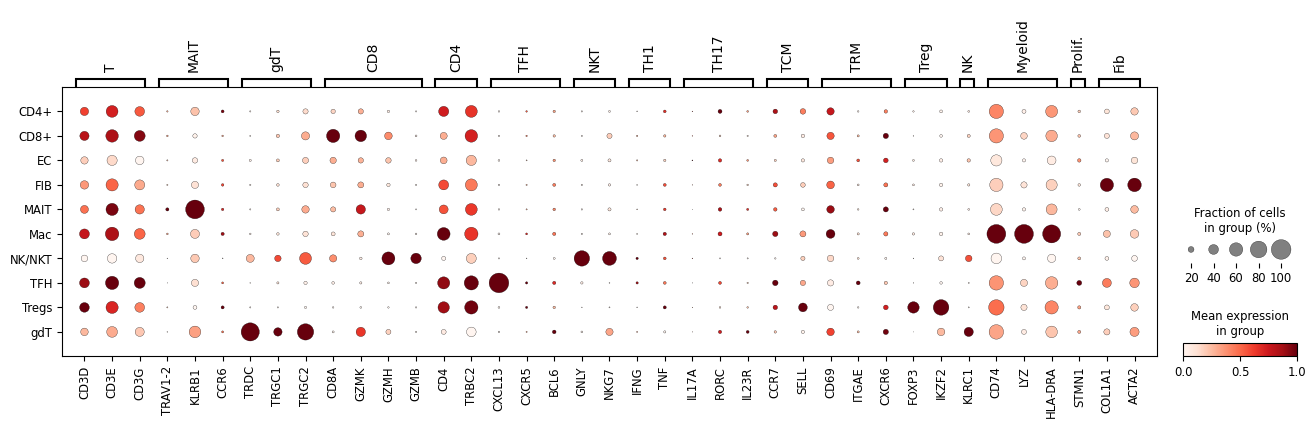

In [156]:
annots_res_20 = dict.fromkeys(ad_t_full.obs["leiden_tcell"].value_counts().index, "")
annots_res_20 = {
    "21": "FIB",
    "1": "CD8+",
    "14": "CD4+",  # Th17 like
    "6": "CD8+",
    "15": "EC",  # mixed
    "7": "CD8+",  # mixed
    "17": "FIB",
    "20": "CD4+",  # maybe Mac
    "19": "Mac",
    "0": "NK/NKT",
    "12": "EC",
    "18": "CD4+",
    "23": "Tregs",
    "4": "CD4+",
    "13": "CD4+",
    "8": "MAIT",
    "10": "FIB",
    "3": "CD4+",
    "9": "EC",
    "11": "gdT",
    "16": "CD4+",  # mixed
    "5": "CD4+",
    "24": "TFH",
    "2": "CD4+",
    "22": "CD8+",  # mixed with B cells
}

ad_t_full.obs["tcell_subtype"] = ad_t_full.obs["leiden_tcell"].map(annots_res_20)
sc.pl.dotplot(
    ad_t_full, markers, groupby="tcell_subtype", standard_scale="var", dendrogram=False
)

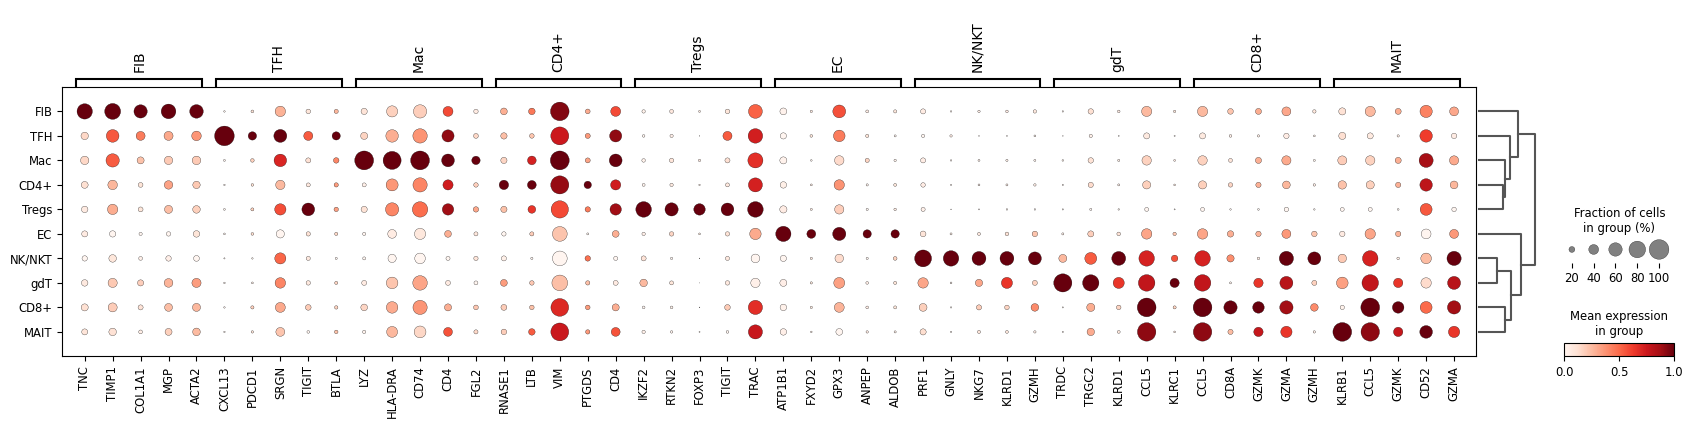

In [157]:
sc.tl.rank_genes_groups(ad_t_full, groupby="tcell_subtype", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(
    ad_t_full, groupby="tcell_subtype", standard_scale="var", n_genes=5, dendrogram=True
)

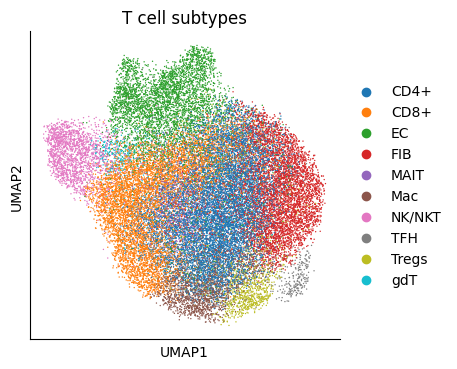

In [158]:
plt.rcParams["figure.figsize"] = (4, 4)
ax = sc.pl.umap(
    ad_t_full,
    color="tcell_subtype",
    # Setting a smaller point size to get prevent overlap
    size=4,
    title="T cell subtypes",
    show=False,
)
# despine
sns.despine(ax=ax)

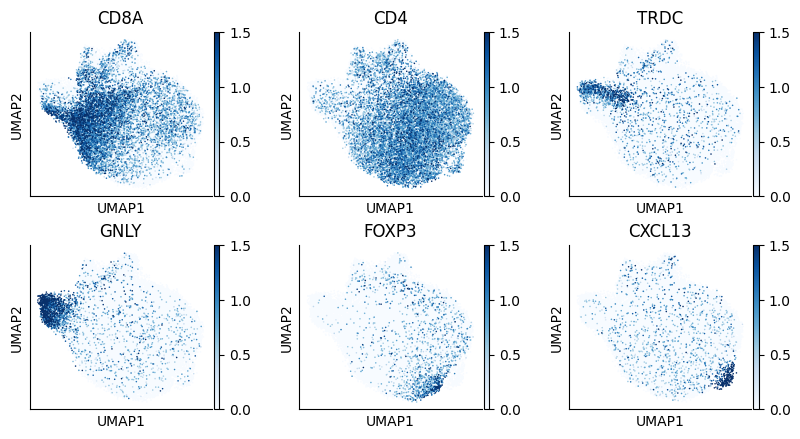

In [159]:
plt.rcParams["figure.figsize"] = (2.3, 2.3)
colors = ["CD8A", "CD4", "TRDC", "GNLY", "FOXP3", "CXCL13"]
axs = sc.pl.umap(
    ad_t_full,
    color=colors,
    # Setting a smaller point size to get prevent overlap
    size=5,
    cmap="Blues",
    vmax=1.5,
    ncols=3,
    hspace=0.3,
    show=False,
)
for ax in axs:
    # despine
    sns.despine(ax=ax)

In [ ]:
# ad_t_full.write_h5ad("data/xenium/processed/04-kidney_tcr_tsub_only.h5ad")

In [ ]:
# inject fixed annotations to ensure reproducibility
import pandas as pd

tcell_subtype_df = pd.read_csv("data/xenium/tcell_subtype.csv", index_col=0)
adata.obs.loc[tcell_subtype_df.index, "tcell_subtype"] = tcell_subtype_df[
    "tcell_subtype"
]

# # save into anndata
# adata.obs["tcell_subtype"] = adata.obs["cell_type_no_tcr"].astype(str)
# adata.obs.loc[ad_t_full.obs_names, "tcell_subtype"] = ad_t_full.obs["tcell_subtype"]
# # replace T with unknown
# adata.obs.loc[adata.obs["tcell_subtype"] == "T", "tcell_subtype"] = "unknown"

adata.obs["tcell_subtype"].value_counts()

tcell_subtype
PT          120985
FIB          79706
Mac          51415
TAL          46477
EC           41864
MDC          21738
PC           19094
IC           18190
VSM/P        16335
CNT          14542
DCT          14132
CD4+          8962
POD           8584
glom. EC      6554
CD8+          6509
PL            6156
B             5862
DTL           5230
PEC           4937
MC            2816
unknown       2241
NK/NKT        1842
Tregs         1158
MAST          1154
MAIT           820
cycMNP         771
N              544
gdT            446
ATL            396
cDC            303
TFH            296
pDC             37
PapE            27
NEU             16
Name: count, dtype: int64

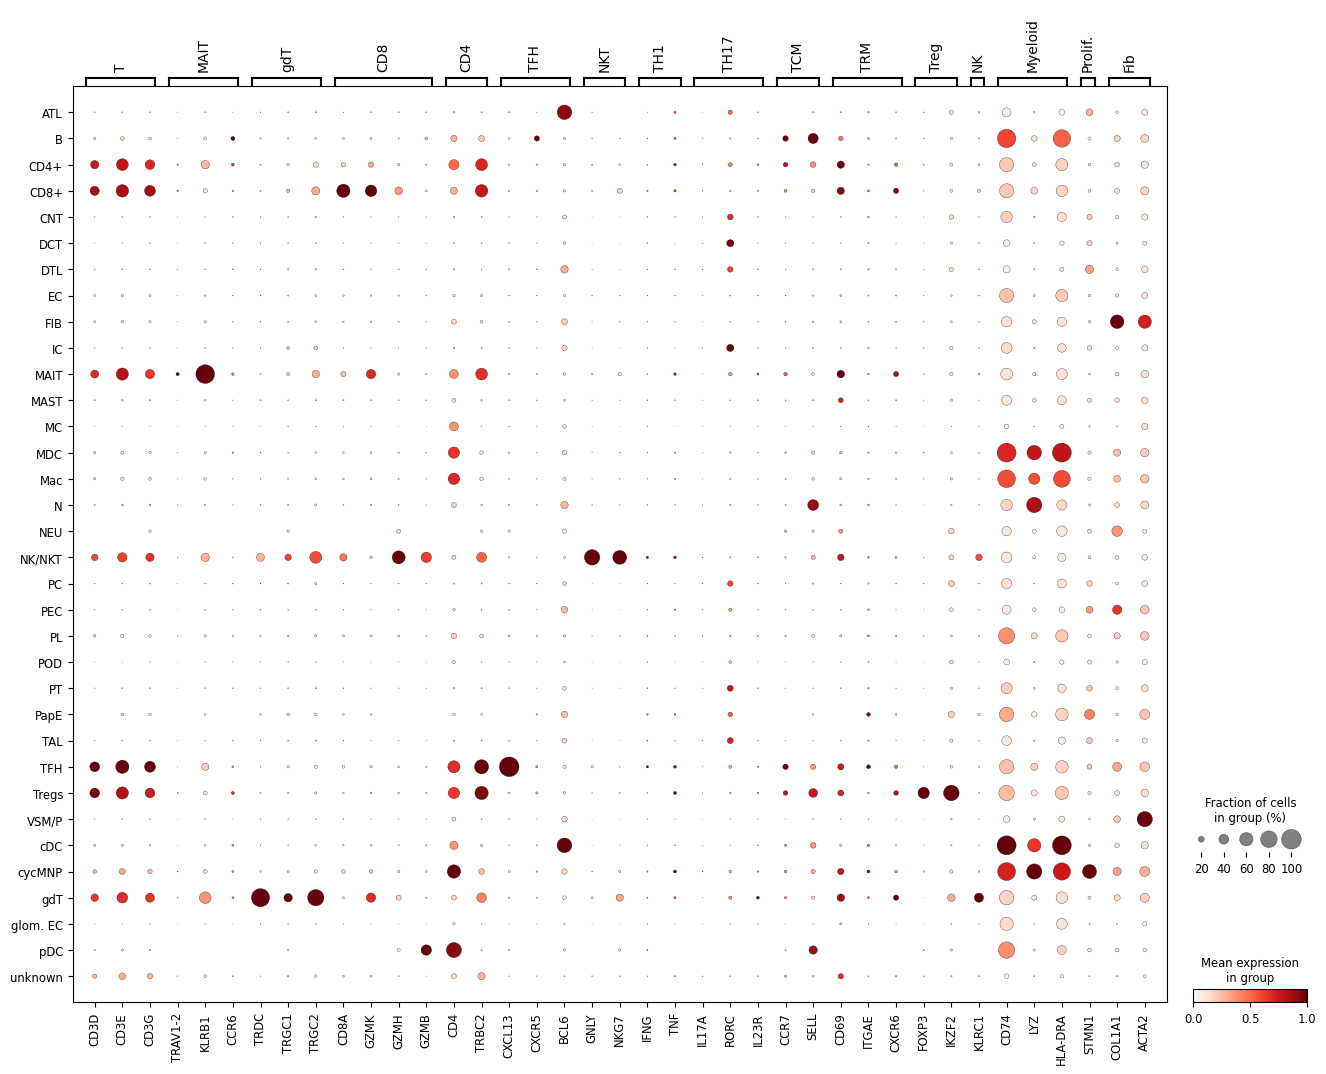

In [126]:
sc.pl.dotplot(adata, markers, groupby="tcell_subtype", standard_scale="var")

In [ ]:
adata.write_h5ad("data/xenium/processed/04-kidney_tcr_tsub.h5ad")